# Bank Customer Churn Analysis
**Dataset:** Churn_Modeling.csv -10,000 Customers, 14 Columns     
**Target Column:** Exited (1= Churned, 0= Stayed)         
**Goal:** Identify key factors driving customer churn using exploratory data analysis       

## 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset  
The dataset contains 10,000 bank customers with 14 features including demographics, account and behavioural data

In [2]:

df = pd.read_csv(r"D:\Bank customer churn analysis project\Churn_Modelling.csv")



## 3. Data Inspection  
Checking dataset dimensions, column names, data types and null counts   
- Dataset contains **10,000 rows and 14 columns**  
- 3 object columns (text): Surname, Geography, Gender  
- 9 integer columns, 2 float rows
- 'RowNumber' and 'CustomerID' are ID columns - no analytical value
  

In [4]:

print(df.shape)
print(df.columns)


(10000, 14)
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


## 4. Missing Value check  
Explicitly verifying null counts acorss all columns  
**Finding:** Zero missing values across all 14 columns 

In [6]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## 5. Discriptive Statistics  
Summary statistics for all numeric columns.  

**Key Findings** 
- Overall churn rate: **20.37%** (2037 out of 10,000 customers)  
- Average customer age:38.9 years
- At least 25% of customers hold **Zero Balance**
- 70% of a customer hold a credit card
- 49% of customers are inactive members  

In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 6. Categorical Analysis  
Exploring distribution of key categorical columns.  
- France accounts for ~50% of customers, Germany and Spain ~25% each.  
- Gender splitt: 55% Male, 45% Female.
- 2037 customers churned (20.37%), 7936 stayed (79.63%)
- Dataset is **imbalanced**  - important consideration for any future modeling 

In [13]:
print(df['Geography'].value_counts())
print(df['Gender'].value_counts())
df['Exited'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64


Exited
0    7963
1    2037
Name: count, dtype: int64

## 7. Churn Rate by Customer Segment  
Using groupby to compare churn rates across key demographic and behavioural segments.  

**Key Findings:** 
- Germany: **32.4%** churn rate - roughly double France (16.2%) and Spain (16.7%)  
- Female customers: **25.1%** churn rate vs Male: 16.5%
- Inactive members: **26.9%** churn rate vs Active: 14.3%

In [14]:
print(df.groupby('Geography')['Exited'].mean())
print(df.groupby('Gender')['Exited'].mean())
df.groupby('IsActiveMember')['Exited'].mean()

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [11]:
df['ActiveStatus'] = df['IsActiveMember'].map({0: 'Inactive', 1: 'Active'})
df['ActiveStatus'].value_counts()

ActiveStatus
Active      5151
Inactive    4849
Name: count, dtype: int64

## 8. Visualisations  
Charts confirming and communicating the findings from sections 6 and 7.

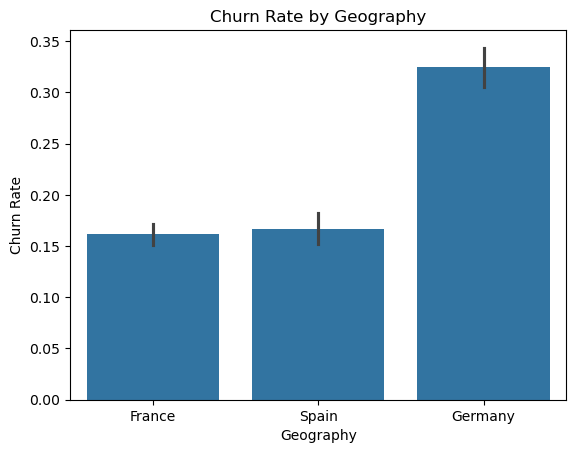

In [6]:
sns.barplot(data = df, x ='Geography', y= 'Exited')
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.show()

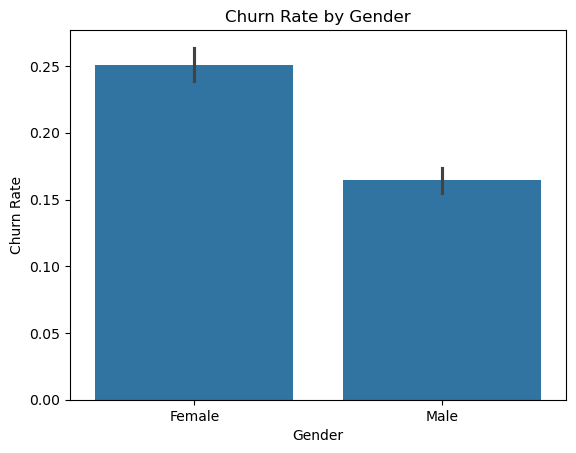

In [8]:
sns.barplot(data = df, x= 'Gender', y='Exited')
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

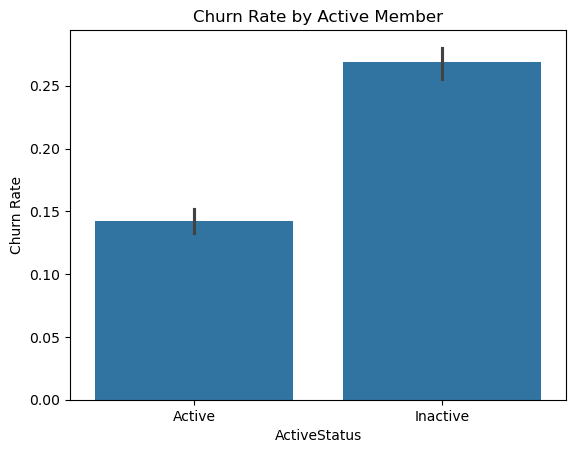

In [12]:
sns.barplot(data = df, x='ActiveStatus', y='Exited')
plt.title('Churn Rate by Active Member')
plt.ylabel('Churn Rate')
plt.show()

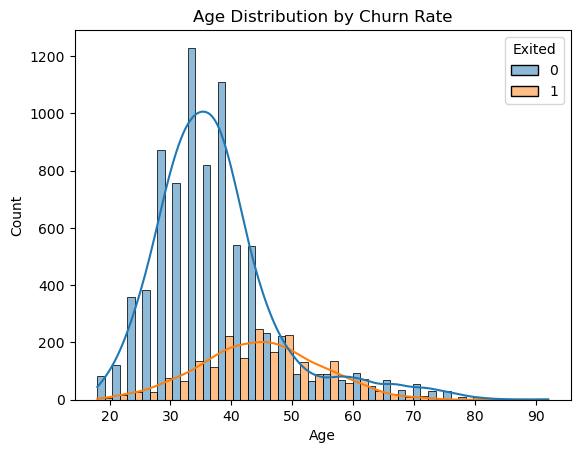

In [4]:
sns.histplot(data = df, x='Age', bins =30,hue= 'Exited',multiple ='dodge', kde= True)
plt.xlabel('Age')
plt.title('Age Distribution by Churn Rate')
plt.show()

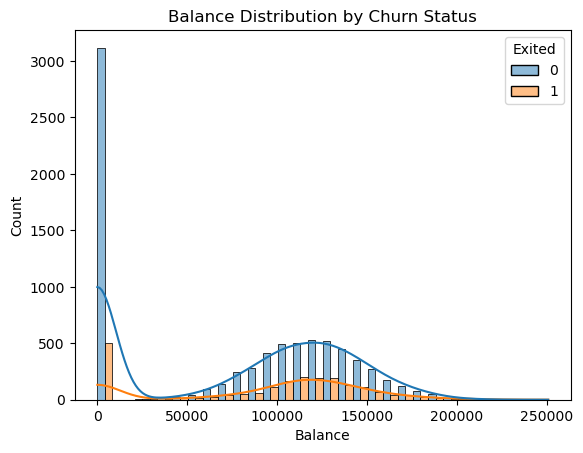

In [8]:
sns.histplot(data = df, x= 'Balance', bins =30, hue= 'Exited', kde =True, multiple = 'dodge')
plt.title('Balance Distribution by Churn Status')
plt.xlabel('Balance')
plt.show()

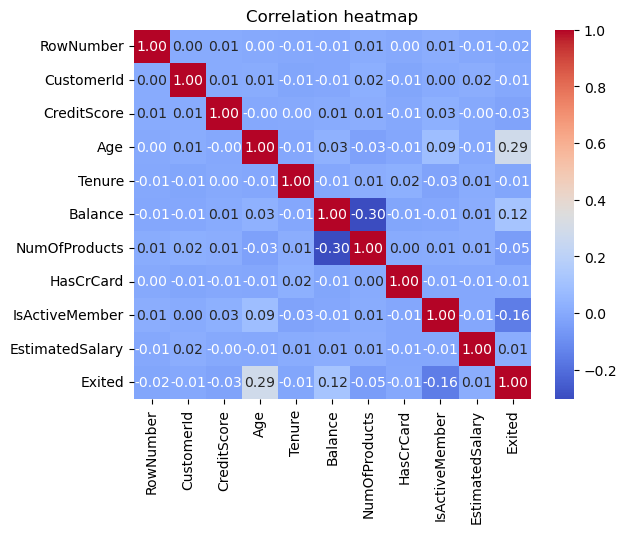

In [6]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation heatmap')
plt.show()

## 9. Key Findings & Business Recommendations

| Factor | Finding | Recommendation |
|---|---|---|
| Churn Rate | 20.37% overall — dataset is imbalanced | Account for imbalance in any future modelling |
| Geography | Germany churns at 32.4% — highest of all regions | Investigate Germany-specific service or pricing issues |
| Gender | Female customers churn at 25.1% vs 16.5% for males | Design targeted retention campaigns for female customers |
| Activity | Inactive members churn at nearly double the rate of active members | Trigger re-engagement campaigns for inactive accounts |
| Age | Churned customers concentrated in 40-60 age range | Offer tailored products for mid-age customers |
| Balance | Mid-to-high balance customers churn most | Priority retention — these are the most valuable customers to keep |